In [1]:
import pandas as pd
import argparse
import numpy as np
import pymc as pm
import arviz as az
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col
import ajr_causalpy_iv as ajr
import pytensor



%load_ext autoreload
%autoreload 2




In [ ]:
priors_1 = {
    "mus": [
        [0, 0, 0, 0, 0, 0],               # β_z  (intercept, slope on logem4)
        [0, 0, 0, 0, 0, 0],            # β_t  (intercept, avexpr)
    ],
    "sigmas": [
        [1000, 1000, 1000, 1000, 1000, 1000],               # β_z block → normal priors with sd=1
        [1000, 1000, 1000, 1000, 1000, 1000]          # β_t block 
    ],
    "eta": 2,                 # LKJ prior parameter
    "lkj_sd": 1,              # LKJ scale parameter
}


# Load the data
data_path = r"C:\Users\B375471\Downloads\Acemoglu_osv\colonial_origins\maketable4\maketable4.dta"
df_ajr = ajr.load_ajr_data(data_path, baseline_only=True)


# Run the model with pre-processed data
iv_p = ajr.run(
    data=df_ajr,  # Pass the filtered dataframe 
    priors=priors_1, 
    draws=1000, 
    tune=500, 
    chains=4, 
    cores=4, 
    loosen_exclusion=False,
    covariates=['asia', 'africa', 'other_cont', 'lat_abst'],
    netcdf_path="ajr_iv_posterior_p.nc"
)

Original dataset size: 163
After baseco == 1 filter: 64
After dropna: 64 observations


c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\site-packages\causalpy\experiments\instrumental_variable.py:161: UserWarning: Warning. The treatment variable is not Binary.
                This is not necessarily a problem but it violates
                the assumption of a simple IV experiment.
                The coefficients should be interpreted appropriately.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\site-packages\pytensor\link\c\cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options

Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 178 seconds.
There were 683 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [likelihood]


Output()

                     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
beta_z[Intercept]   3.539  1.414   0.840    5.940      0.075    0.057   
beta_z[avexpr]      0.759  0.225   0.385    1.185      0.012    0.010   
beta_z[asia]       -0.804  0.346  -1.487   -0.197      0.012    0.008   
beta_z[africa]     -0.636  0.282  -1.160   -0.110      0.016    0.013   
beta_z[other_cont] -0.448  0.615  -1.569    0.645      0.026    0.017   
beta_z[lat_abst]   -0.116  1.045  -2.059    1.814      0.049    0.030   
beta_t[Intercept]   8.227  0.861   6.775    9.889      0.031    0.023   
beta_t[logem4]     -0.438  0.160  -0.741   -0.153      0.005    0.005   
beta_t[asia]        0.398  0.521  -0.614    1.374      0.017    0.010   
beta_t[africa]     -0.184  0.405  -0.955    0.559      0.017    0.009   
beta_t[other_cont]  0.917  0.818  -0.664    2.353      0.024    0.012   
beta_t[lat_abst]    1.672  1.422  -0.927    4.339      0.066    0.043   

                    ess_bulk  ess_tail  r_hat  
be

array([[<Axes: title={'center': 'beta_z\nIntercept'}>,
        <Axes: title={'center': 'beta_z\navexpr'}>,
        <Axes: title={'center': 'beta_z\nasia'}>],
       [<Axes: title={'center': 'beta_z\nafrica'}>,
        <Axes: title={'center': 'beta_z\nother_cont'}>,
        <Axes: title={'center': 'beta_z\nlat_abst'}>]], dtype=object)

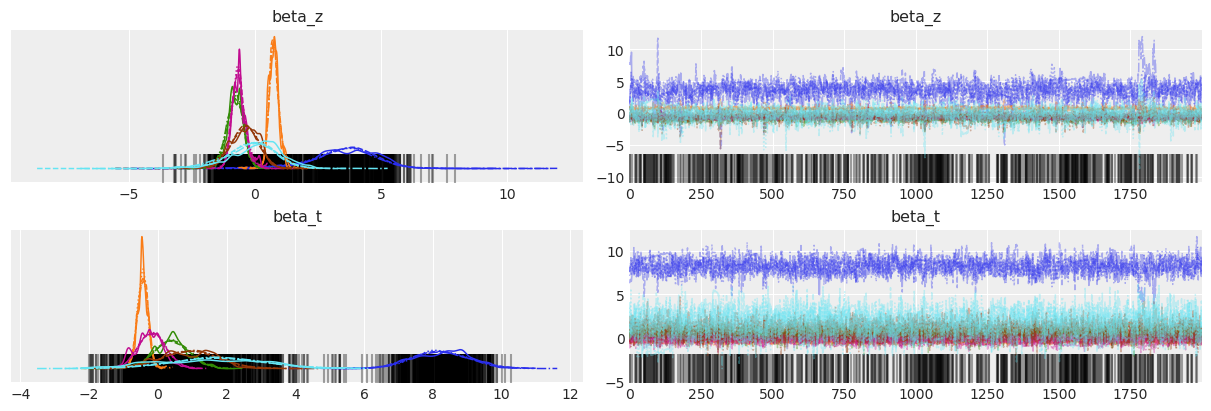

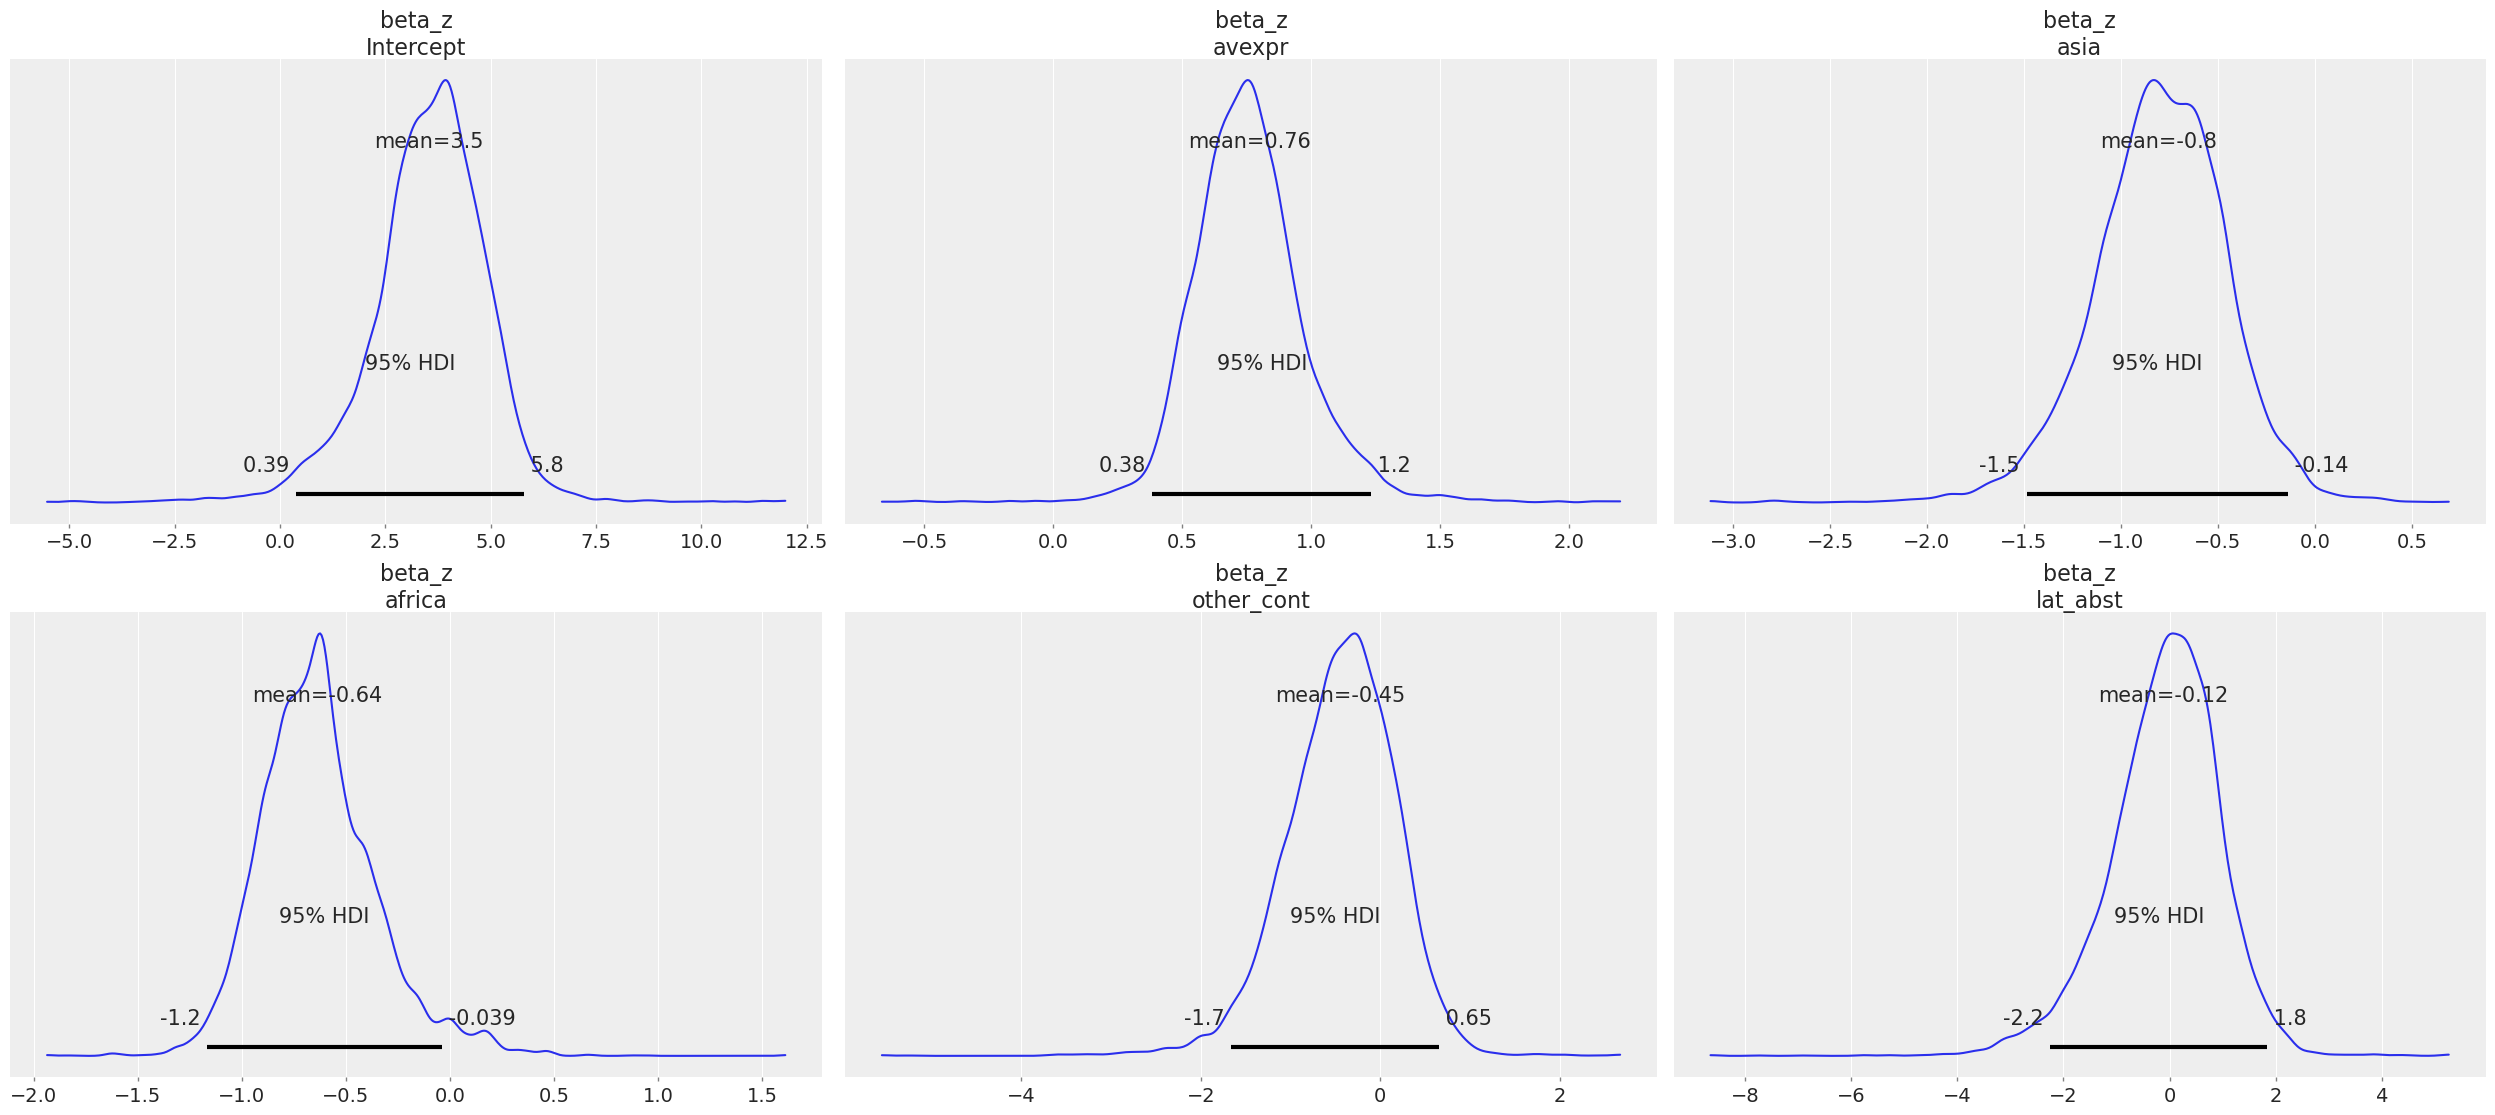

In [3]:
idata2 = az.from_netcdf("ajr_iv_posterior_p.nc")
az.plot_trace(idata2, var_names=["beta_z", "beta_t"])
az.plot_posterior(idata2, var_names=["beta_z"], hdi_prob=0.95)

Computing correlations for 8000 posterior samples...

=== BAYESIAN EXCLUSION RESTRICTION TEST ===
Posterior median correlation: 0.121
95% HDI: [-0.227, 0.448]
HDI contains zero: True
✓ PASS: Cannot reject exclusion restriction (HDI contains 0)


C:\Users\B375471\AppData\Local\Temp\ipykernel_6724\3797748897.py:101: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


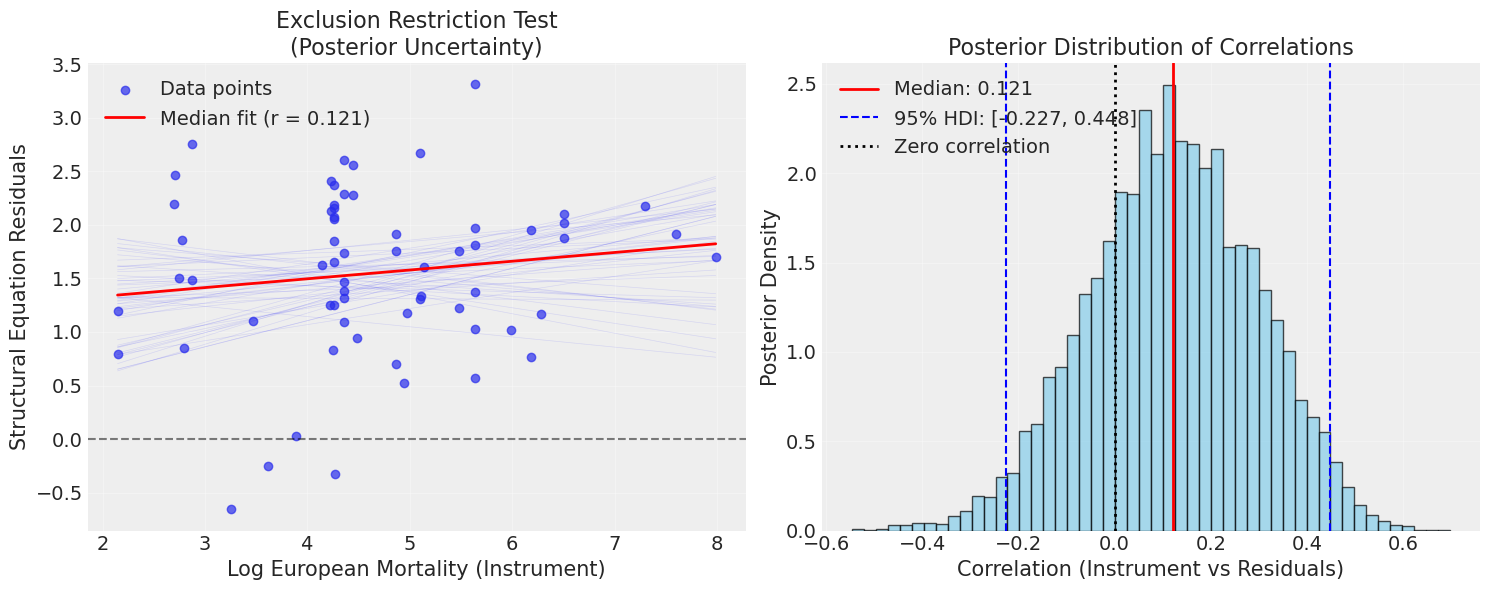


Interpretation:
✓ MODERATE SUPPORT: Modest correlation but HDI contains 0

Diagnostic Information:
Standard deviation of posterior correlations: 0.1744
Range of correlations: [-0.546, 0.698]


In [4]:
# Check if residuals from both equations are uncorrelated with instrument
# This tests the exclusion restriction using BAYESIAN POSTERIOR SAMPLES
import xarray as xr

# Use the same filtered data and predictions from previous cells
first_stage_preds = idata2.posterior['mu'].isel(mu_dim_1=0)  # First stage (avexpr) predictions
structural_preds = idata2.posterior['mu'].isel(mu_dim_1=1)  # Structural (logpgp95) predictions

# Calculate residuals for each posterior sample
observed_logpgp95 = df_ajr['logpgp95'].values
observed_logem4 = df_ajr['logem4'].values

# Calculate correlations for each posterior sample
n_chains, n_draws, n_obs = structural_preds.shape
correlations_posterior = []

print(f"Computing correlations for {n_chains * n_draws} posterior samples...")

for chain in range(n_chains):
    for draw in range(n_draws):
        # Get residuals for this posterior sample
        pred_logpgp95 = structural_preds[chain, draw, :].values
        residuals = observed_logpgp95 - pred_logpgp95
        
        # Calculate correlation between instrument and residuals
        corr = np.corrcoef(observed_logem4, residuals)[0, 1]
        correlations_posterior.append(corr)

correlations_posterior = np.array(correlations_posterior)

# Calculate HDI from posterior samples
hdi_lower = np.percentile(correlations_posterior, 2.5)
hdi_upper = np.percentile(correlations_posterior, 97.5)
corr_median = np.median(correlations_posterior)

print(f"\n=== BAYESIAN EXCLUSION RESTRICTION TEST ===")
print(f"Posterior median correlation: {corr_median:.3f}")
print(f"95% HDI: [{hdi_lower:.3f}, {hdi_upper:.3f}]")

# Test if HDI contains zero
contains_zero = hdi_lower <= 0 <= hdi_upper
print(f"HDI contains zero: {contains_zero}")

if contains_zero:
    print("✓ PASS: Cannot reject exclusion restriction (HDI contains 0)")
else:
    print("✗ FAIL: Evidence against exclusion restriction (HDI excludes 0)")

# Visualization using posterior samples
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left plot: Scatter with median residuals
median_residuals = observed_logpgp95 - structural_preds.mean(['chain', 'draw']).values
ax1.scatter(observed_logem4, median_residuals, alpha=0.7, label='Data points')

# Show uncertainty with individual posterior samples (subsample for clarity)
n_sample_lines = 50
sample_indices = np.random.choice(len(correlations_posterior), n_sample_lines, replace=False)

for i, idx in enumerate(sample_indices):
    chain_idx = idx // n_draws
    draw_idx = idx % n_draws
    
    pred_sample = structural_preds[chain_idx, draw_idx, :].values
    residuals_sample = observed_logpgp95 - pred_sample
    
    # Fit line for this sample
    slope, intercept = np.polyfit(observed_logem4, residuals_sample, 1)
    line_x = np.linspace(observed_logem4.min(), observed_logem4.max(), 100)
    line_y = slope * line_x + intercept
    
    ax1.plot(line_x, line_y, 'blue', alpha=0.1, linewidth=0.5)

# Overall median line
median_slope, median_intercept = np.polyfit(observed_logem4, median_residuals, 1)
line_x = np.linspace(observed_logem4.min(), observed_logem4.max(), 100)
median_line_y = median_slope * line_x + median_intercept
ax1.plot(line_x, median_line_y, 'red', linewidth=2, label=f'Median fit (r = {corr_median:.3f})')

ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax1.set_xlabel('Log European Mortality (Instrument)')
ax1.set_ylabel('Structural Equation Residuals')
ax1.set_title('Exclusion Restriction Test\n(Posterior Uncertainty)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right plot: Posterior distribution of correlations
ax2.hist(correlations_posterior, bins=50, alpha=0.7, density=True, color='skyblue', edgecolor='black')
ax2.axvline(corr_median, color='red', linestyle='-', linewidth=2, label=f'Median: {corr_median:.3f}')
ax2.axvline(hdi_lower, color='blue', linestyle='--', label=f'95% HDI: [{hdi_lower:.3f}, {hdi_upper:.3f}]')
ax2.axvline(hdi_upper, color='blue', linestyle='--')
ax2.axvline(0, color='black', linestyle=':', linewidth=2, label='Zero correlation')
ax2.set_xlabel('Correlation (Instrument vs Residuals)')
ax2.set_ylabel('Posterior Density')
ax2.set_title('Posterior Distribution of Correlations')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary assessment
print(f"\nInterpretation:")
if abs(corr_median) < 0.1 and contains_zero:
    print("✓ STRONG SUPPORT: Low correlation and HDI contains 0")
elif abs(corr_median) < 0.2 and contains_zero:
    print("✓ MODERATE SUPPORT: Modest correlation but HDI contains 0")
elif contains_zero:
    print("⚠ WEAK SUPPORT: High correlation but HDI still contains 0")
else:
    print("✗ NO SUPPORT: Correlation significantly different from 0")

# Additional diagnostic: Show how much uncertainty comes from posterior vs sampling
print(f"\nDiagnostic Information:")
print(f"Standard deviation of posterior correlations: {np.std(correlations_posterior):.4f}")
print(f"Range of correlations: [{np.min(correlations_posterior):.3f}, {np.max(correlations_posterior):.3f}]")